In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bmms_overview = pd.read_excel('../Data/Input/BMMS_overview.xls')
rmms_overview = pd.read_excel('../Data/Input/RMMS_overview.xls')

roads_overview = pd.read_csv('../Data/Input/_roads.tsv', sep = "\t")
roads_LRP_overview = pd.read_csv('../Data/Input/Roads_InfoAboutEachLRP.csv')

C:\Users\matsm\AppData\Local\Temp\ipykernel_12208\3629466442.py:4: DtypeWarning: Columns (0: Unnamed: 571, 1: Unnamed: 574, 2: Unnamed: 577, 3: Unnamed: 580, 4: Unnamed: 583, 5: Unnamed: 586, 6: Unnamed: 589, 7: Unnamed: 592, 8: Unnamed: 595, 9: Unnamed: 598, 10: Unnamed: 601, 11: Unnamed: 604, 12: Unnamed: 607, 13: Unnamed: 610, 14: Unnamed: 613, 15: Unnamed: 616, 16: Unnamed: 619, 17: Unnamed: 622, 18: Unnamed: 625, 19: Unnamed: 628, 20: Unnamed: 631, 21: Unnamed: 634, 22: Unnamed: 637, 23: Unnamed: 640, 24: Unnamed: 643, 25: Unnamed: 646, 26: Unnamed: 649, 27: Unnamed: 652, 28: Unnamed: 655, 29: Unnamed: 658, 30: Unnamed: 661, 31: Unnamed: 664, 32: Unnamed: 667, 33: Unnamed: 670, 34: Unnamed: 673, 35: Unnamed: 676, 36: Unnamed: 679, 37: Unnamed: 682, 38: Unnamed: 685, 39: Unnamed: 688, 40: Unnamed: 691, 41: Unnamed: 694, 42: Unnamed: 697, 43: Unnamed: 700, 44: Unnamed: 703, 45: Unnamed: 706, 46: Unnamed: 709, 47: Unnamed: 712, 48: Unnamed: 715, 49: Unnamed: 718, 50: Unnamed: 721, 51

# Conversion Panda dataframe
The roads.tsv is in wide formate. Since we need the information about the chainage of the road LRPs, we should update the document Roads_InfoAboutEachLRP with the processed _roads.tsv (see DataCleaning_Roads notebook). Such that the updates latitudes and longitudes of the LRP's are in the document Road_InfoAboutEachLRP.

This is the approach we aimed to do:

1. _roads.tsv is transferred to a long format
2. Road_InfoAboutEachLRP to panda dataframe
2. Merge the column 'lat' and 'lon' from the _roads.tsv into the Road_InfoAboutEachLRP

This last step is not executed, so we worked with the Roads_InfoAboutEachLRP dataset.

In [3]:
cols = roads_overview.columns.tolist()

## rename unnamed columns
start = cols.index("lon2") + 1
tail = cols[start:]

new_tails = []
idx = 3
for i in range(0, len(tail), 3):
    new_tails.extend([f"lrp{idx}", f"lat{idx}", f"lon{idx}"])
    idx += 1

new_cols = cols[:start] + new_tails
new_cols

roads = roads_overview.copy()
roads.columns = new_cols

# Reshape wide -> long
long = pd.wide_to_long(
    roads,
    stubnames=["lrp", "lat", "lon"],
    i="road",
    j="idx",
    sep="",
    suffix=r"\d+"
).reset_index()

# Clean rows
roads_long = long[long["lrp"].notna() & (long["lrp"].astype(str).str.strip() != "")]
roads_long["lat"] = pd.to_numeric(long["lat"], errors="coerce")
roads_long["lon"] = pd.to_numeric(long["lon"], errors="coerce")

## Check for outliers bridges
1. Find the LRP before and after the bridge, based on the chainage
2. Get de lon and lat of the three LRP's
3. Calculate distance between LRP bridge and the two LRP's of the roads
4. If distance is outside threshold for both > incorrect

In [4]:
def point_to_segment_distance(lat, lon, lat1, lon1, lat2, lon2):
    """
    Calculate perpendicular distance from a point to a line segment (in meters)
    using geodesic distances for better accuracy.
    """
    # Convert points to 2D Cartesian approx for short distances
    # Using equirectangular projection
    R = 6371000  # Earth radius in meters
    x1 = np.radians(lon1) * R * np.cos(np.radians((lat1 + lat2) / 2))
    y1 = np.radians(lat1) * R
    x2 = np.radians(lon2) * R * np.cos(np.radians((lat1 + lat2) / 2))
    y2 = np.radians(lat2) * R
    x0 = np.radians(lon) * R * np.cos(np.radians((lat1 + lat2) / 2))
    y0 = np.radians(lat) * R

    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        # segment is a point
        return np.hypot(x0 - x1, y0 - y1)

    t = np.clip(((x0 - x1) * dx + (y0 - y1) * dy) / (dx**2 + dy**2), 0, 1)
    proj_x = x1 + t * dx
    proj_y = y1 + t * dy
    return np.hypot(x0 - proj_x, y0 - proj_y)

In [5]:
def find_out_of_range_bridges(
    bridges_df,
    roads_df,
    chainage_col='chainage',
    lat_col='lat',
    lon_col='lon',
    lrp_col='lrp',
    road_col='road',
    threshold_m=9000
):
    results = []

    # sort the df's by roadname
    for bridge_idx, bridge in bridges_df.iterrows():
        #keeping all original columns
        bridge_data = bridge.to_dict()
        road_name = bridge[road_col]

        roads = roads_df[roads_df[road_col] == road_name].sort_values(chainage_col)

        if roads.empty:
            # If bridges are not linked to a road, mark them as unmatched in new columns 'status'
            bridge_data['status'] = 'unmatched-road'
            bridge_data['perp_distance'] =  np.nan
            results.append(bridge_data)
            continue

        road_chainage = roads[chainage_col].to_numpy()

        # Find in between which road LRP's the bridge belongs, based on the chainage information
        idx = np.searchsorted(road_chainage, bridge[chainage_col], side='right')

        # Mark bridges that are before the first road lrp or behind last road lrp as out-of-range
        if idx == 0 or idx >= len(road_chainage):
            bridge_data['status'] = 'out-of-range'
            bridge_data['perp_distance'] =  np.nan
            results.append(bridge_data)
            continue

        # Define the index of the road LRP before the bridge, s, and after the bridge, e,
        s = roads.iloc[idx - 1]
        e = roads.iloc[idx]

        # Calculate the distance of the bridge to the road segment
        perp_dist = point_to_segment_distance(
            bridge[lat_col], bridge[lon_col],
            s[lat_col], s[lon_col],
            e[lat_col], e[lon_col]
        )

        # If bridges are further away than the treshold, mark as out-of-range
        bridge_data['status'] = 'ok' if perp_dist <= threshold_m else 'out-of-range'
        bridge_data['perp_distance'] =  perp_dist

        #store coordinates of the lrp before and after bridge
        bridge_data['s_lat'] = s[lat_col]
        bridge_data['s_lon'] = s[lon_col]
        bridge_data['e_lat'] = e[lat_col]
        bridge_data['e_lon'] = e[lon_col]

        results.append(bridge_data)

    return pd.DataFrame(results).set_index(bridges_df.index)

In [6]:
df_bridges_status = find_out_of_range_bridges(
    bmms_overview,
    roads_LRP_overview,
    chainage_col='chainage',
    lat_col='lat',
    lon_col='lon',
    lrp_col='lrp',
    road_col='road',
    threshold_m=9000
)

In [7]:
df_bridges_status.head()

,road,km,type,LRPName,name,length,condition,structureNr,roadName,chainage,...,sub-division,lat,lon,EstimatedLoc,status,perp_distance,s_lat,s_lon,e_lat,e_lon
0,N1,1.800,Box Culvert,LRP001a,.,11.30,A,117861,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,1.8,...,Narayanganj-1,23.702889,90.450389,bcs1,ok,181.501369,23.702139,90.451972,23.697889,90.460583
1,N1,4.925,Box Culvert,LRP004b,.,6.60,A,117862,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,4.925,...,Narayanganj-1,23.693611,90.478833,bcs1,ok,173.806970,23.693805,90.480527,23.694750,90.488500
2,N1,8.976,PC Girder Bridge,LRP008b,Kanch pur Bridge.,394.23,A,119889,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,8.976,...,Narayanganj-1,23.704583,90.518833,road_precise,ok,321.052764,23.706083,90.521527,23.702528,90.527388
3,N1,10.880,Box Culvert,LRP010b,NOYAPARA CULVERT,6.30,A,112531,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.88,...,Vitikandi,23.699833,90.530722,bcs1,ok,546.833081,23.696639,90.534805,23.694361,90.537611
4,N1,10.897,Box Culvert,LRP010c,ADUPUR CULVERT,6.30,A,112532,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.897,...,Vitikandi,23.699667,90.530722,bcs1,ok,916.547582,23.694361,90.537611,23.692277,90.541055


In [8]:
bmms_overview.info()

<class 'pandas.DataFrame'>
RangeIndex: 21407 entries, 0 to 21406
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   road              21407 non-null  str    
 1   km                21406 non-null  float64
 2   type              21407 non-null  str    
 3   LRPName           21407 non-null  str    
 4   name              21060 non-null  object 
 5   length            21398 non-null  float64
 6   condition         21407 non-null  str    
 7   structureNr       21407 non-null  int64  
 8   roadName          21406 non-null  str    
 9   chainage          21407 non-null  object 
 10  width             18290 non-null  float64
 11  constructionYear  18289 non-null  float64
 12  spans             18290 non-null  float64
 13  zone              21406 non-null  str    
 14  circle            21406 non-null  str    
 15  division          21406 non-null  str    
 16  sub-division      21406 non-null  str    
 17  lat 

## Correct bridges out of range
1. Select bridges out of range
2. Calculate the midpoint between the road LRP before and after the bridge
3. Raplace new latitude and longitude in the bmms_overview

In [9]:
def correct_bridges_coordinates(bridges_df,
                                     lat_col='lat',
                                     lon_col='lon',
                                     status_col='status',
                                     s_lat_col='s_lat',
                                     s_lon_col='s_lon',
                                     e_lat_col='e_lat',
                                     e_lon_col='e_lon',
):
    """
    Update bridge latitude and longitude to the midpoint of the segment
    (s_lat/s_lon → e_lat/e_lon) for bridges with a certain status.

    Parameters:
        bridges_df: DataFrame from find_out_of_range_bridges_full
        lat_col, lon_col: names of the bridge coordinates columns
        status_col: column containing 'ok', 'out-of-range', etc.
        s_lat_col, s_lon_col, e_lat_col, e_lon_col: segment start/end columns
        snap_status: which status to snap (default: 'ok')

    Returns:
        DataFrame with updated lat/lon
    """
    bridges_updated = bridges_df.copy()
    bmms_overview_updated = bmms_overview.copy()

    mask = bridges_updated[status_col] == 'out-of-range'

    # Only update bridges that match the desired status
    bridges_updated.loc[mask, lat_col] = (
        bridges_updated.loc[mask, s_lat_col] + bridges_updated.loc[mask, e_lat_col]
    ) / 2
    bridges_updated.loc[mask, lon_col] = (
        bridges_updated.loc[mask, s_lon_col] + bridges_updated.loc[mask, e_lon_col]
    ) / 2

    # replace the column lat and lon in the original bmms_overview with the new ones
    bmms_overview_updated.loc[bridges_updated.index, lat_col] = bridges_updated[lat_col]
    bmms_overview_updated.loc[bridges_updated.index, lon_col] = bridges_updated[lon_col]

    return bridges_updated, bmms_overview_updated



In [10]:
bridges_updated, bmms_overview_updated = correct_bridges_coordinates(df_bridges_status,
                                     lat_col='lat',
                                     lon_col='lon',
                                     status_col='status',
                                     s_lat_col='s_lat',
                                     s_lon_col='s_lon',
                                     e_lat_col='e_lat',
                                     e_lon_col='e_lon',)

In [11]:
bmms_overview_updated.info()

<class 'pandas.DataFrame'>
RangeIndex: 21407 entries, 0 to 21406
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   road              21407 non-null  str    
 1   km                21406 non-null  float64
 2   type              21407 non-null  str    
 3   LRPName           21407 non-null  str    
 4   name              21060 non-null  object 
 5   length            21398 non-null  float64
 6   condition         21407 non-null  str    
 7   structureNr       21407 non-null  int64  
 8   roadName          21406 non-null  str    
 9   chainage          21407 non-null  object 
 10  width             18290 non-null  float64
 11  constructionYear  18289 non-null  float64
 12  spans             18290 non-null  float64
 13  zone              21406 non-null  str    
 14  circle            21406 non-null  str    
 15  division          21406 non-null  str    
 16  sub-division      21406 non-null  str    
 17  lat 

In [12]:
bmms_overview.info()

<class 'pandas.DataFrame'>
RangeIndex: 21407 entries, 0 to 21406
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   road              21407 non-null  str    
 1   km                21406 non-null  float64
 2   type              21407 non-null  str    
 3   LRPName           21407 non-null  str    
 4   name              21060 non-null  object 
 5   length            21398 non-null  float64
 6   condition         21407 non-null  str    
 7   structureNr       21407 non-null  int64  
 8   roadName          21406 non-null  str    
 9   chainage          21407 non-null  object 
 10  width             18290 non-null  float64
 11  constructionYear  18289 non-null  float64
 12  spans             18290 non-null  float64
 13  zone              21406 non-null  str    
 14  circle            21406 non-null  str    
 15  division          21406 non-null  str    
 16  sub-division      21406 non-null  str    
 17  lat 

In [13]:
bmms_overview.head()

,road,km,type,LRPName,name,length,condition,structureNr,roadName,chainage,width,constructionYear,spans,zone,circle,division,sub-division,lat,lon,EstimatedLoc
0,N1,1.800,Box Culvert,LRP001a,.,11.30,A,117861,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,1.8,19.5,2005.0,2.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.702889,90.450389,bcs1
1,N1,4.925,Box Culvert,LRP004b,.,6.60,A,117862,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,4.925,35.4,2006.0,1.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.693611,90.478833,bcs1
2,N1,8.976,PC Girder Bridge,LRP008b,Kanch pur Bridge.,394.23,A,119889,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,8.976,NaN,NaN,NaN,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.704583,90.518833,road_precise
3,N1,10.880,Box Culvert,LRP010b,NOYAPARA CULVERT,6.30,A,112531,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.88,12.2,1992.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699833,90.530722,bcs1
4,N1,10.897,Box Culvert,LRP010c,ADUPUR CULVERT,6.30,A,112532,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.897,12.2,1984.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699667,90.530722,bcs1


In [16]:
bmms_overview_updated.to_excel("../Data/Output_v2/bmms_overview_updated.xlsx")

In [17]:
import matplotlib.pyplot as plt

def plot_road_with_bridges_updated(df_bridges_status, bmms_overview_updated,
                                   roads_df, road_name,
                                   chainage_col='chainage',
                                   lat_col='lat', lon_col='lon',
                                   road_col='road', status_col='status'):
    """
    Plot a single road with its bridges in two figures:
        1) Original bridge coordinates with status
        2) Updated bridge coordinates (bmms_overview_updated) with the same status
    Ensures both subplots have the same lat/lon axis ranges.

    Parameters:
        df_bridges_status: output of find_out_of_range_bridges
        bmms_overview_updated: BMMS overview with updated coordinates
        roads_df: DataFrame of road LRPs
        road_name: name of the road to plot
        chainage_col, lat_col, lon_col, road_col: column names
        status_col: column name for bridge status
    """

    # Select road LRPs
    road_lrps = roads_df[roads_df[road_col] == road_name].sort_values(chainage_col)
    if road_lrps.empty:
        print(f"No LRPs found for road: {road_name}")
        return

    # Select bridges on this road
    road_bridges_original = df_bridges_status[df_bridges_status[road_col] == road_name]
    road_bridges_updated = bmms_overview_updated[bmms_overview_updated[road_col] == road_name]

    # Merge status info into updated bridges
    road_bridges_updated = road_bridges_updated.merge(
        road_bridges_original[[status_col]],
        left_index=True, right_index=True, how='left'
    )

    # Define colors for statuses
    status_colors = {
        'ok': 'green',
        'out-of-range': 'red',
        'unmatched-road': 'orange'
    }

    # -------------------------
    # Compute axis limits to be the same for both subplots
    # -------------------------
    all_lats = pd.concat([road_lrps[lat_col], road_bridges_original[lat_col], road_bridges_updated[lat_col]])
    all_lons = pd.concat([road_lrps[lon_col], road_bridges_original[lon_col], road_bridges_updated[lon_col]])
    lat_min, lat_max = all_lats.min(), all_lats.max()
    lon_min, lon_max = all_lons.min(), all_lons.max()

    # Optional: add a small padding
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    lat_limits = (lat_min - lat_pad, lat_max + lat_pad)
    lon_limits = (lon_min - lon_pad, lon_max + lon_pad)

    # -------------------------
    # Create figure with two subplots
    # -------------------------
    plt.figure(figsize=(12, 5))

    # Figure 1: Original bridges
    plt.subplot(1, 2, 1)
    plt.plot(road_lrps[lon_col], road_lrps[lat_col], color='gray', linewidth=2, label='Road')
    for status, group in road_bridges_original.groupby(status_col):
        plt.scatter(group[lon_col], group[lat_col],
                    color=status_colors.get(status, 'blue'),
                    label=f'Bridge: {status}',
                    s=80, edgecolors='k', zorder=5)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f"{road_name} - Original Bridges")
    plt.grid(True)
    plt.legend()
    plt.xlim(lon_limits)
    plt.ylim(lat_limits)

    # Figure 2: Updated bridges
    plt.subplot(1, 2, 2)
    plt.plot(road_lrps[lon_col], road_lrps[lat_col], color='gray', linewidth=2, label='Road')
    for status, group in road_bridges_updated.groupby(status_col):
        plt.scatter(group[lon_col], group[lat_col],
                    color=status_colors.get(status, 'blue'),
                    label=f'Bridge: {status}',
                    s=80, edgecolors='k', zorder=5)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f"{road_name} - Updated Bridges")
    plt.grid(True)
    plt.legend()
    plt.xlim(lon_limits)
    plt.ylim(lat_limits)

    plt.tight_layout()
    plt.show()


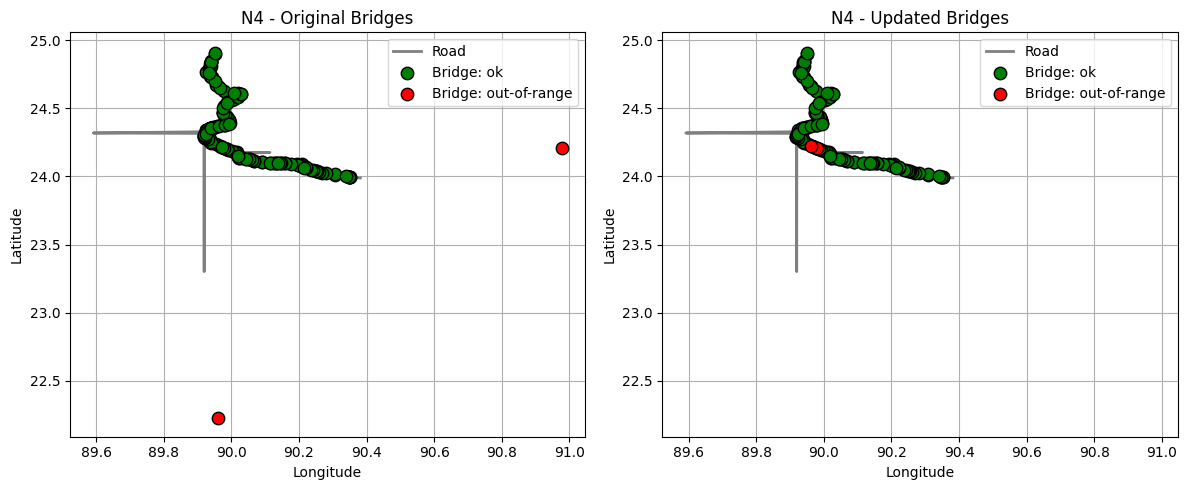

In [18]:
plot_road_with_bridges_updated(df_bridges_status, bmms_overview_updated,
                               roads_LRP_overview, 'N4', chainage_col='chainage',
                                   lat_col='lat', lon_col='lon',
                                   road_col='road', status_col='status')